# LEARNING OBJECTIVE

This notebook illustrates planar 2D Stokes corner flows. Solutions are expressed in terms of the streamfunction in planar polar coordinates, which is then used to visualize the flows. Numerical methods are used to determine the allowed solutions for Moffatt's problem.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np
from scipy import optimize as op

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# TAYLOR'S SCRAPER

## Solution for the streamfunction

The solution for Taylor's scraper problem, in terms of the streamfuntion made dimensionless by $LU_0$, where $L$ is some characteristic horizontal scale of the wedge, and $U_0$ is the wall velocity, is:
$$
  \psi(r,\theta) = r G(\theta),
$$
where
$$
  G(\theta) = \frac{1}{\alpha^2 - \sin^2 \alpha} \left[\alpha^2 \sin \theta - (\sin^2 \alpha) \theta \cos \theta + ( \cos \alpha \sin \alpha - \alpha) \theta \sin \theta \right].
$$
We have dropped the stars on the dimensionless variables for convenience. The wedge angle is $\alpha$ and $0\le \theta\le\alpha$.

Observe that $G$ satisfies the boundary conditions
\begin{align*}
  G'(0) &= 1,\\
  G'(\alpha) &= 0,\\
  G(0) = G(\alpha) &= 0 .
\end{align*}

We can use SymPy to check if this solution satisfies $\nabla^4\psi=0$ by noting that $\nabla^4\psi = \nabla^2(\nabla^2\psi) = \nabla\cdot\nabla(\nabla\cdot\nabla\psi)$. (The Laplacian is defined as "div grad".)

In [2]:
# create a planar polar coordinate system,
# same as 3D cylindrical coordinate system, if we ignore z
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='cylindrical',
                  vector_names=("r", "th", "z"),
                  variable_names=("R", "Th", "Z"))

# print change of coordinates formula for our reference
cp.transformation_to_parent()

In [3]:
# define the streamfunction for Taylor's scraper problem
alpha = sp.symbols('alpha')
psi1 = cp.R/(alpha**2 - sp.sin(alpha)**2) \
       *( alpha**2*sp.sin(cp.Th) - sp.sin(alpha)**2*cp.Th*sp.cos(cp.Th)
          + (sp.cos(alpha)*sp.sin(alpha) - alpha)*cp.Th*sp.sin(cp.Th) )

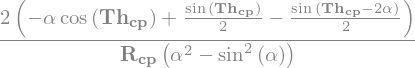

In [4]:
# Laplacian of psi is not zero !
sp.simplify(divergence(gradient(psi1)))

In [5]:
# Biharmonic of psi is zero !
sp.simplify(divergence(gradient(divergence(gradient(psi1)))))

In [6]:
# create a lambdified version of psi for evaluation and plotting
psi_Taylor = sp.lambdify([cp.R,cp.Th,alpha], psi1, modules=['numpy'])

## Visualization of the streamlines

In [ ]:
def plot_func(α):
  # range, square domain
  xymax = 10
  x, y = np.meshgrid( np.linspace(0, xymax, num=500),
                      np.linspace(0, xymax, num=500) )
  r = np.sqrt(x**2 + y**2)
  th = np.arctan2(y,x)

  fig, ax = plt.subplots()

  z = psi_Taylor(r,th,α*np.pi/180)

  # remove any streamlines outside the wedge 0 <= theta <= alpha
  z[np.where(np.abs(th) > α*np.pi/180)] = 0

  strm = ax.contour( x, y, z,
                    linewidths=2, # note this function takes linewidthS, plural...
                    cmap=colormaps['YlGnBu_r'] )

  ax.clabel(strm, inline=True, fontsize=10)

  ax.set_xlabel('$x$')
  ax.set_ylabel('$y$')

  plt.show()

# alpha on the slider is in degrees
interact(plot_func, α = widgets.FloatSlider( value = 55,
                                             min   = 10,
                                             max   = 85,
                                             step  = 5 ) );

interactive(children=(FloatSlider(value=55.0, description='α', max=85.0, min=10.0, step=5.0), Output()), _dom_…

# MOFFATT'S EDDIES

## Solution for the streamfunction

The solution to [Moffatt's problem](https://www.cambridge.org/core/journals/journal-of-fluid-mechanics/article/abs/viscous-and-resistive-eddies-near-a-sharp-corner/6F1FC07C3D919ADB9CE0FF75180FF1D2), once again in terms of a dimensionless streamfunction, is
$$
  \psi(r,\theta) = r^{n+1} G(\theta;n),
$$
where
$$
  G(\theta;n) = A \cos[(n+1)\theta] + B \sin[(n+1)\theta] + C \cos[(n-1)\theta] + D \sin[(n-1)\theta],
$$
subject to
\begin{align*}
  G(\theta = \pm\alpha;n) &= 0,\\
  G'(\theta = \pm\alpha;n) &= 0.\\
\end{align*}

The wedge's total angle is now $2\alpha$, so the domain we solve the problem is $\{(r,\theta) \;|\; r>0, \;-\alpha \le \theta \le +\alpha\}$.

By symmetry, the conditions at $\theta=+\alpha$ yield the same relations as at $\theta=-\alpha$. The $\theta\mapsto-\theta$ symmetry also requires that $B = D = 0$, leaving only the cosine terms.

We can use SymPy to check if this solution satisfies $\nabla^4\psi=0$.

In [8]:
# create a planar polar coordinate system,
# same as cylindrical if we ignore z
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='cylindrical',
                  vector_names=("r", "th", "z"),
                  variable_names=("R", "Th", "Z"))

# print change of coordinates formula for our reference
cp.transformation_to_parent()

In [9]:
# define the streamfunction for Moffatt's problem
alpha = sp.symbols('alpha', real='True')
n, A, C = sp.symbols('n, A, C')
psi2 = cp.R**(n+1)*(A*sp.cos((n+1)*cp.Th) + C*sp.cos((n-1)*cp.Th))

In [10]:
# Laplacian of psi is not zero !
sp.simplify(divergence(gradient(psi2)))

In [11]:
# Biharmonic of psi is zero !
sp.simplify(divergence(gradient(divergence(gradient(psi2)))))

In [12]:
# create a lambdified version of psi for evaluation and plotting
psi_Moffatt = sp.lambdify( [cp.R,cp.Th,n,alpha],
                           psi2.subs(A,-sp.cos((n-1)*alpha)/sp.cos((n+1)*alpha)).subs(C,1),
                           modules=['numpy'] )

## Possible solutions for $n$

The _homogeneous_ BCs on $G$ lead to a linear system:

In [37]:
Eq1 = sp.Eq(-psi2.diff(cp.R).subs(cp.Th,alpha) , 0)
Eq1.simplify()

In [38]:
Eq2 = sp.Eq(1/cp.R*psi2.diff(cp.Th).subs(cp.Th,alpha) , 0)
Eq2.simplify()

The only solution of this system is the trivial solution $A=C=0$, _unless_ the determinant of the linear system is zero (singular matrix), that is:
\begin{align*}
  &\left|\begin{matrix} \cos[(n+1)\alpha] & \cos[(n-1)\alpha] & \\ -(n+1)\sin[(n+1)\alpha] & -(n-1)\sin[(n-1)\alpha] \end{matrix} \right|  \\ 
  &\qquad\qquad 
  = -(n-1)\sin[(n-1)\alpha]\cos[(n+1)\alpha] + (n+1)\sin[(n+1)\alpha]  \cos[(n-1)\alpha] = 0.
\end{align*}

Using SymPy, we can simplify this equation:

In [13]:
solv_cond = sp.trigsimp(-(n-1)*sp.sin((n-1)*alpha)*sp.cos((n+1)*alpha)
                        +(n+1)*sp.sin((n+1)*alpha)*sp.cos((n-1)*alpha))
display(solv_cond)

So, the condition for having nontrivial $A$, $C$ solutions is
$$
  n\sin(2\alpha) + \sin(2n\alpha) = 0.
$$
Since $n$ is undetermined, perhaps we can make this happen (or at least for some values of $\alpha$).

We can plot the left-hand side of the condition above as a function of $n$ for different values of $2\alpha$ to see if it has real solutions (zero crossings).

In [14]:
# create a lambdified version for evaluation and plotting
nl_eq_lhs = sp.lambdify([n,alpha], solv_cond, modules=['numpy'])

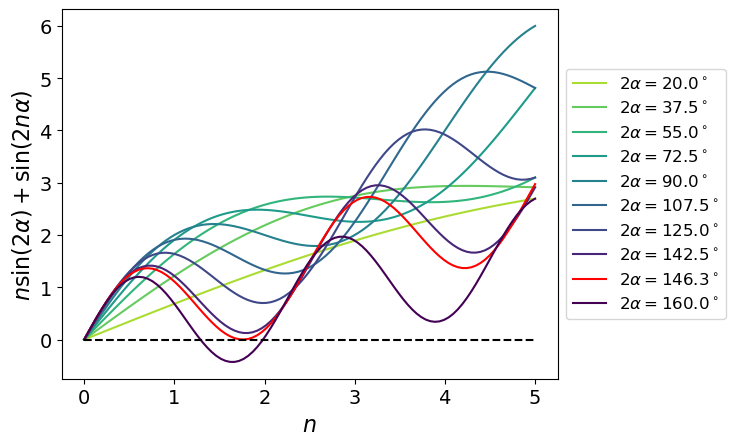

In [15]:
plot_alpha = np.linspace(10,80,9)
alpha_crit = 73.15
nplot = np.linspace(0,5,100)

fig, ax = plt.subplots()

# sequential colormap with gradient that looks nice, also try 'cool' or 'summer'
# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['viridis_r']

for angle in plot_alpha:
  # plot the critical angle in red in the correct order wrt to the others
  if angle >= alpha_crit:
    ax.plot(nplot, nl_eq_lhs(nplot,alpha_crit*np.pi/180),
        color='red',
        label=r'$2\alpha=146.3^\circ$')
  ax.plot(nplot, nl_eq_lhs(nplot,angle*np.pi/180),
          color=cmap(angle/plot_alpha.max()),
          label=rf'$2\alpha={2*angle:.1f}^\circ$')

ax.plot(nplot,0*nplot,ls='dashed',color='black')

ax.set_xlabel('$n$')
ax.set_ylabel(r'$n\sin(2\alpha) + \sin(2n\alpha)$')

# move legend off the plot because it is too long
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

Indeed, as claimed in papers & books, no real solutions exist for $2\alpha\lesssim146.3^\circ$.

Now, can we find the solutions for $n$, whether real or complex? The real case is easy, but the complex case is not; numerical rootfinders are usually only good for real solutions.

Either way, following Moffatt, we set $n = p + i q$, which transforms the single transcendental equation for complex $n$ into two real ones (by taking real and imaginary parts). Let's use SymPy again:


In [16]:
p, q = sp.symbols('p, q', real='True')
peq = sp.Eq(sp.re(solv_cond.subs(n,p+sp.I*q).expand(complex = True)).trigsimp(),0)
qeq = sp.Eq(sp.im(solv_cond.subs(n,p+sp.I*q).expand(complex = True)).trigsimp(),0)
display(peq)
display(qeq)

So, the problem is reduced to finding roots (solutions $p$ and $q$) of the latter **two** coupled equations, given $2\alpha$.


In [17]:
# pick an angle < 73.15 deg, for example 28.5
plot_alpha = 28.5/2*np.pi/180

# lambdify nonlinear eqs for p and q for numerical use
# group arguments in conveniently for scipy optimize
nl_eq_lhs_n = sp.lambdify([[p,q],alpha], [qeq.lhs, peq.lhs], modules=['numpy'])

# solve the nonlinear eqs for p and q
# local minima exist; initial guess x0 can be important
# based on Moffatt's Table I, we try p0 = 4/(2*alpha), q0 = 2/(2*alpha)
pq0 = [4/(2*plot_alpha), 2/(2*plot_alpha)]
nsol = op.root(nl_eq_lhs_n, x0=pq0, args=(plot_alpha, ), tol=1e-12)

print(nsol)
# nsol.x contains the array with the solution for p and q

 message: The solution converged.
 success: True
  status: 1
     fun: [-1.776e-15 -8.882e-16]
       x: [ 8.485e+00  4.434e+00]
  method: hybr
    nfev: 14
    fjac: [[-9.802e-01  1.978e-01]
           [-1.978e-01 -9.802e-01]]
       r: [-2.032e+00  1.980e-01  2.080e+00]
     qtf: [ 2.727e-14 -4.113e-13]


To validate this code (see also the manual for [`scipy.optimize.OptimizeResult`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.OptimizeResult.html#scipy.optimize.OptimizeResult) to learn what the output above means), we can reproduce some of the results from Table I of [Moffatt's paper](https://www.cambridge.org/core/journals/journal-of-fluid-mechanics/article/abs/viscous-and-resistive-eddies-near-a-sharp-corner/6F1FC07C3D919ADB9CE0FF75180FF1D2). For example, $p\approx 2.27$, $q\approx 0.76$ for $2\alpha=110^\circ$.

For the configuration later realized in experiments by [Taneda](https://journals.jps.jp/doi/abs/10.1143/JPSJ.46.1935?journalCode=jpsj), $2\alpha = 28.5^\circ$. [Eggers & Fontelos](https://www.cambridge.org/core/books/singularities-formation-structure-and-propagation/F239878E447F48C5603A0F70AC103AA5) report $p\approx 8.49$, $q \approx 4.43$ for this case.

## Visualization of the streamlines

To see the flow pattern, we can solve for $A = -C \cos[(n-1)\alpha]/\cos[(n+1)\alpha]$, from $G(\theta=\pm\alpha;n)=0$, and take $C=1$ without loss of generality. Then, we substitute the numerical value of $n$ found above (possibly complex)  for the chosen angle $\alpha$.

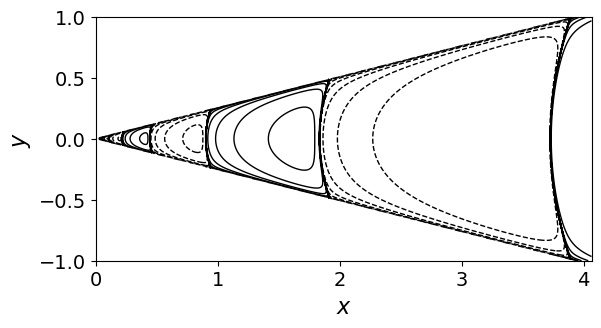

In [18]:
# custom rectangular domain, longer in x for smaller angles
xymax = 1
x, y = np.meshgrid( np.linspace(0, xymax/np.sin(plot_alpha), num=1000),
                    np.linspace(-xymax, xymax, num=1000) )

r = np.sqrt(x**2 + y**2)
th = np.arctan2(y,x)

fig, ax = plt.subplots()

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
# to mantain angles in the plot
ax.set_aspect('equal', 'box')

# take the real part, important for complex c
z = np.real(psi_Moffatt(r,th,nsol.x[0]+1j*nsol.x[1],plot_alpha))

# remove any streamlines outside the wedge -alpha <= theta <= alpha
z[np.where(np.abs(th) > plot_alpha)] = np.nan

# due to the exponentially damped nature of the vortices,
# we need logarithmic spacing of the contour levels
loglevels = np.logspace(-15,3,20)
consts = np.concatenate((-np.flip(loglevels), loglevels))

# we will not use colors or labelclips4ss because of the logarithmic spacing
strm = ax.contour( x, y, z, consts,
                   linewidths=1, colors='black' )